# Setup

In [239]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import random

PATH_VENDAS = 'Data/raw/fato_vendas_varejo.parquet'
PATH_METAS = 'Data/raw/metas_vendas_varejo.parquet'
PATH_FILIAIS = 'Data/raw/filiais.parquet'

os.getcwd()
pd.set_option('display.float_format', '{:.2f}'.format)

### Leitura de dados

In [150]:
df_vendas = pd.read_parquet(PATH_VENDAS)
df_metas = pd.read_parquet(PATH_METAS)
df_filiais = pd.read_parquet(PATH_FILIAIS)

# Análise

## Natureza dos dados
Vamos fazer investigação inicial dos dados disponíveis, analisando coisas como:
- Número de linhas
- Valores nulos e inconsistentes
- Distribuição dos dados
- Janela temporal

### Vendas

Observações:
- Sem valores nulos
- 1 ano de dados
- 125 filiais unicas
- Tabela grande
- Faturamento máximo absurdamente grande, investigar possível B2B ou erro de lançamento

In [156]:
# Estrutura, tipos de dados e consumo de memoria
df_vendas.info()
display(df_vendas.head())

<class 'pandas.DataFrame'>
RangeIndex: 5534166 entries, 0 to 5534165
Data columns (total 5 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   codigo_documento_saida  int64  
 1   codigo_filial           int64  
 2   data_emissao            str    
 3   quantidade              float64
 4   faturamento             float64
dtypes: float64(2), int64(2), str(1)
memory usage: 332.5 MB


,codigo_documento_saida,codigo_filial,data_emissao,quantidade,faturamento
0,122854,1803,2025-07-07 00:00:00.000,6.00,135.00
1,214007,1743,2025-07-18 00:00:00.000,9.00,222.63
2,176406,1794,2025-07-17 00:00:00.000,3.00,389.45
3,999220,1614,2025-07-01 00:00:00.000,39.00,707.20
4,181499,1761,2025-06-02 00:00:00.000,15.00,194.43


In [157]:
# Numero de valores unicos
colunas_analise = ['codigo_filial','codigo_documento_saida']

for coluna in colunas_analise:
    print(f"Valores únicos em '{coluna}': {len(df_vendas[coluna].unique())}")

# Distribuição dos valores numéricos e ts
df_vendas['data_emissao'] = pd.to_datetime(df_vendas['data_emissao'])
display(df_vendas[['quantidade','faturamento','data_emissao']].describe())

Valores únicos em 'codigo_filial': 125
Valores únicos em 'codigo_documento_saida': 1755854


,quantidade,faturamento,data_emissao
count,5534166.00,5534166.00,5534166
mean,7.78,208.95,2025-07-10 11:48:00.156902
min,3.00,0.03,2025-01-01 00:00:00
25%,3.00,45.48,2025-04-09 00:00:00
50%,6.00,106.73,2025-07-14 00:00:00
75%,9.00,252.76,2025-10-13 00:00:00
max,21600.00,627414.75,2025-12-31 00:00:00
std,40.51,1005.36,NaN


### Metas

Observações:
- Sem valores nulos
- Investigar extremos de meta (0 e 413956.34)
- 125 filiais unicas

In [158]:
# Estrutura, tipos de dados e consumo de memoria
df_metas.info()
display(df_metas.head())

<class 'pandas.DataFrame'>
RangeIndex: 42896 entries, 0 to 42895
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   codigo_filial    42896 non-null  int64  
 1   data_meta_venda  42896 non-null  str    
 2   meta_n_med       42896 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.9 MB


,codigo_filial,data_meta_venda,meta_n_med
0,1740,2025-01-01 03:00:00.000,4652.32
1,1830,2025-01-01 03:00:00.000,7870.85
2,1524,2025-01-01 03:00:00.000,6144.89
3,1677,2025-01-01 03:00:00.000,11840.37
4,1758,2025-01-01 03:00:00.000,9554.39


In [159]:
# Numero de valores unicos
colunas_analise = ['codigo_filial']

for coluna in colunas_analise:
    print(f"Valores únicos em '{coluna}': {len(df_metas[coluna].unique())}")
    
# Distribuição dos valores numéricos e ts
df_metas['data_meta_venda'] = pd.to_datetime(df_metas['data_meta_venda'])
display(df_metas[['meta_n_med','data_meta_venda']].describe())

Valores únicos em 'codigo_filial': 125


,meta_n_med,data_meta_venda
count,42896.00,42896
mean,27969.85,2025-07-05 01:32:31.063036
min,0.00,2025-01-01 03:00:00
25%,18272.51,2025-04-05 03:00:00
50%,24647.02,2025-07-06 03:00:00
75%,33038.51,2025-10-05 03:00:00
max,413956.34,2025-12-31 03:00:00
std,17684.89,NaN


### Filiais

Observações:
- Sem valores nulos
- Colunas de valores binários serão transformadas em numéricas para modelagem
- UF constante -> deletar
- codigo_filial unicos -> 124 (investigar divergência com vendas e metas)
- codigo_filial estava como object, o padrão é int64

In [151]:
# Estrutura, tipos de dados e consumo de memoria
df_filiais.info()
df_filiais['codigo_filial'] = df_filiais['codigo_filial'].astype(int)
display(df_filiais.head())

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   codigo_filial         124 non-null    object 
 1   faixa_vida            124 non-null    str    
 2   localidade            124 non-null    str    
 3   uf                    124 non-null    str    
 4   tipo_estabelecimento  124 non-null    str    
 5   delivery              124 non-null    str    
 6   metragem_area_venda   124 non-null    float64
 7   panvel_clinic         124 non-null    str    
 8   estacionamento        124 non-null    str    
 9   atendimento_24_horas  124 non-null    str    
dtypes: float64(1), object(1), str(8)
memory usage: 15.2+ KB


,codigo_filial,faixa_vida,localidade,uf,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas
0,1761,MAIS DE 3 ANOS,APUCARANA,PR,BAIRRO,SIM,503.56,SIM,SIM,NÃO
1,1740,MAIS DE 3 ANOS,LONDRINA,PR,CENTRO,NÃO,531.01,SIM,SIM,NÃO
2,1689,MAIS DE 3 ANOS,LONDRINA,PR,BAIRRO,NÃO,521.74,NÃO,SIM,NÃO
3,1611,MAIS DE 3 ANOS,LONDRINA,PR,BAIRRO,NÃO,565.20,SIM,SIM,NÃO
4,1764,MAIS DE 3 ANOS,LONDRINA,PR,CENTRO,NÃO,572.17,SIM,SIM,NÃO


In [41]:
# Distribuição dos valores
display(df_filiais[['metragem_area_venda']].describe())

,metragem_area_venda
count,124.00
mean,510.70
std,101.20
min,263.76
25%,470.55
50%,511.11
75%,549.50
max,1140.73


In [224]:
# Confirmação de valores unicos
colunas_analise = ['delivery', 'panvel_clinic', 'estacionamento', 'atendimento_24_horas', 'faixa_vida', 'uf']

for coluna in colunas_analise:
    print(f"Valores únicos em '{coluna}': {df_filiais[coluna].unique()}")

print(f"Valores únicos em 'codigo_filial': {len(df_filiais['codigo_filial'].unique())}")

Valores únicos em 'delivery': <ArrowStringArray>
['SIM', 'NÃO']
Length: 2, dtype: str
Valores únicos em 'panvel_clinic': <ArrowStringArray>
['SIM', 'NÃO']
Length: 2, dtype: str
Valores únicos em 'estacionamento': <ArrowStringArray>
['SIM', 'NÃO']
Length: 2, dtype: str
Valores únicos em 'atendimento_24_horas': <ArrowStringArray>
['NÃO', 'SIM']
Length: 2, dtype: str
Valores únicos em 'faixa_vida': <ArrowStringArray>
['MAIS DE 3 ANOS', 'MENOS DE 1 ANO', 'ENTRE 2-3 ANOS', 'ENTRE 1-2 ANOS']
Length: 4, dtype: str
Valores únicos em 'uf': <ArrowStringArray>
['PR']
Length: 1, dtype: str
Valores únicos em 'codigo_filial': 124


In [226]:
# Distribuição de valores:
colunas_analise = ['faixa_vida','localidade','tipo_estabelecimento']

for coluna in colunas_analise:
    print(f"Valores em '{coluna}': {df_filiais[coluna].value_counts()}\n")

Valores em 'faixa_vida': faixa_vida
MAIS DE 3 ANOS    93
MENOS DE 1 ANO    12
ENTRE 1-2 ANOS    11
ENTRE 2-3 ANOS     8
Name: count, dtype: int64

Valores em 'localidade': localidade
CURITIBA                53
LONDRINA                14
MARINGA                 13
CASCAVEL                 4
SAO JOSE DOS PINHAIS     3
PONTA GROSSA             3
FOZ DO IGUACU            3
TOLEDO                   3
ARAPONGAS                2
CAMPO MOURAO             2
CIANORTE                 2
PARANAVAI                2
PINHAIS                  2
UMUARAMA                 2
FRANCISCO BELTRAO        2
GUARAPUAVA               2
APUCARANA                1
TELEMACO BORBA           1
CAMBE                    1
SARANDI                  1
PIRAQUARA                1
PARANAGUA                1
CAMPO LARGO              1
ARAUCARIA                1
GOIOERE                  1
MEDIANEIRA               1
PATO BRANCO              1
COLOMBO                  1
Name: count, dtype: int64

Valores em 'tipo_estabelecimento':

## Investigão e exploração

### Filial fantasma
- A "filial fantasma" é a 1704, que possui valores próximos a média das outras filias.
- A data máxima é 2025-08-18, diferenciando das demais, que vão até dezembro de 2025.
    - Possível fechamento?
    - A filial deve ser descartada da modelagem
- Em um cenário real seria questionada a falta de dados e solicitado mais informações da filial 1704.

In [185]:
# Filial que apareceu em Metas e Vendas, mas não em filiais.
filial_faltando = list(set(df_vendas['codigo_filial']) - set(df_filiais['codigo_filial']))
print(f"Filial faltando: {filial_faltando}")

# Agregando vendas por filial para comparar médias
df_vendas_group = df_vendas.groupby(['codigo_filial']).agg({
    'faturamento': 'mean',
    'quantidade': 'mean',
    'data_emissao': 'max'
}).reset_index()

df_vendas_group.head()

Filial faltando: [1704]


,codigo_filial,faturamento,quantidade,data_emissao
0,1500,138.76,6.08,2025-12-31
1,1503,203.17,8.05,2025-12-31
2,1506,222.22,7.85,2025-12-31
3,1509,155.80,6.35,2025-12-31
4,1512,194.03,8.12,2025-12-31


In [186]:
# Comparação do padrão das filiais com a 1704
print(f"""Média de faturamento geral: {df_vendas_group.faturamento.mean():.2f}
Média de quantidade geral: {df_vendas_group.quantidade.mean():.2f}
Média das datas máximas: {df_vendas_group.data_emissao.mean()}\n""")

print(f"Média de faturamento, quantidade e data máxima da filial 1704:")
display(df_vendas_group[df_vendas_group['codigo_filial']==1704])

Média de faturamento geral: 210.55
Média de quantidade geral: 8.11
Média das datas máximas: 2025-12-29 22:04:48

Média de faturamento, quantidade e data máxima da filial 1704:


,codigo_filial,faturamento,quantidade,data_emissao
63,1704,186.42,7.16,2025-08-18


In [188]:
df_vendas_group.data_emissao.value_counts()

data_emissao
2025-12-31    124
2025-08-18      1
Name: count, dtype: int64

### Faturamento grande na fato_vendas

- Um percentual de linha extremamente baixo (0.00019% dos valores) é responsável por faturamentos absurdamente altos
- Algumas filiais tem padrões sazonais de faturamento maior. Tratar isso como erro é remover uma fatia gigante do faturamento real das filiais.
- Filiais 1848, 1782, 1683 se destacam.
- Não existe correlação aparente com metragem.
- Quase todas tem mais de 3 anos, mas isso ja é pradrão nas filiais. O destaque é a Top 1 loja estar na faixa dos 1-2 ANOS
- Curitiba concentra 53 de 124 das lojas. No entanto, quando olhamos o Top 10 de tickets gigantes, a capital aparece apenas 1 vez (a 1551).
    - Isso pode sugerir que as lojas de Curitiba vivem de faturamento baixo, enquanto as do interior servem mais como um HUB regional/B2B.
    - O modelo deve conseguir prever esses saltos sazonais

<Axes: >

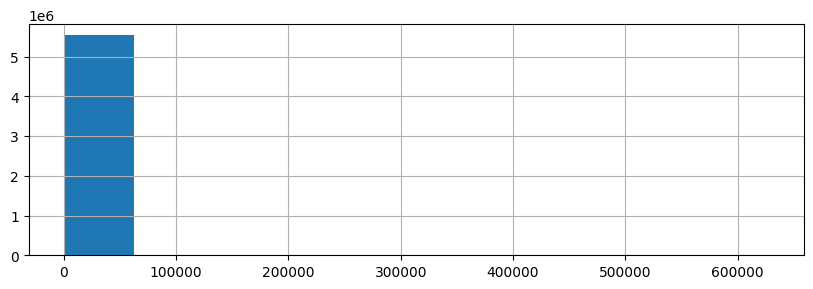

In [ ]:
# Histograma
display(df_vendas.faturamento.hist(figsize=(10, 3)))

Tamanho da df filtrada: 1070, 0.00019% dos valores


<Axes: >

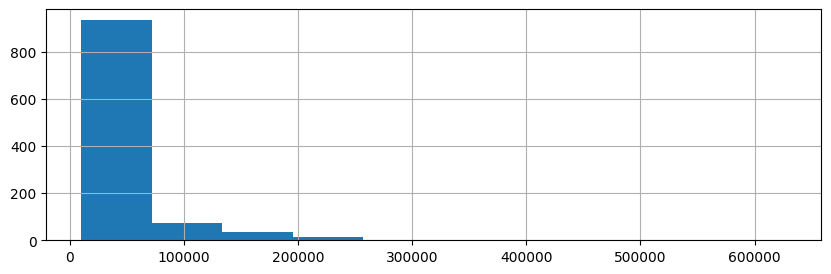

In [219]:
# Linhas a partir de 10000 de faturamento
df_vendas_altos_valores = df_vendas[df_vendas['faturamento'] > 10000]
print(f"Tamanho da df filtrada: {len(df_vendas_altos_valores)}, {np.round(len(df_vendas_altos_valores)/len(df_vendas),5)}% dos valores")

# Histograma dos valores altos
df_vendas_altos_valores['faturamento'].hist(figsize=(10, 3))

In [228]:
# Identificando as lojas com os maiores tickets da base
top_tickets = df_vendas.nlargest(len(df_vendas_altos_valores), 'faturamento')[['codigo_filial', 'faturamento', 'data_emissao']]

# Contando quantas vezes cada loja aparece no Top de faturamento
frequencia_top_lojas = top_tickets['codigo_filial'].value_counts()

print(f"Filiais que mais aparecem nos {len(df_vendas_altos_valores)} tickets extremos:")
display(frequencia_top_lojas.head(10))

Filiais que mais aparecem nos 1070 tickets extremos:


codigo_filial
1848    102
1782     93
1683     81
1761     45
1767     40
1794     38
1884     35
1551     35
1791     34
1851     33
Name: count, dtype: int64

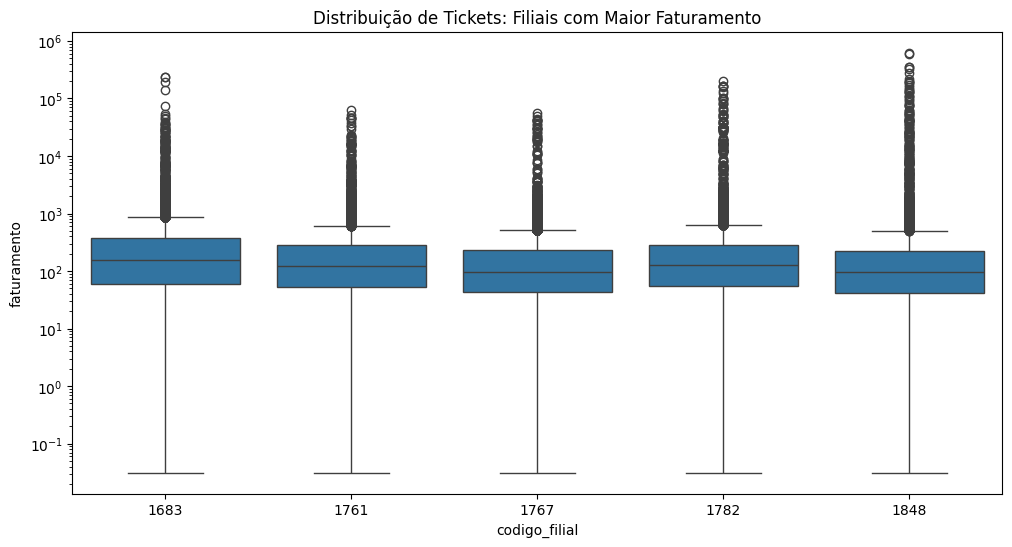

In [229]:
# Top 5 lojas identificadas
top_lojas_ids = frequencia_top_lojas.index[:5]
df_subset = df_vendas[df_vendas['codigo_filial'].isin(top_lojas_ids)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_subset, x='codigo_filial', y='faturamento')
plt.yscale('log') # Escala logarítmica pra conseguir ver os tickets
plt.title('Distribuição de Tickets: Filiais com Maior Faturamento')
plt.show()

In [232]:
# Filtrando o cadastro e exibindo os atributos
perfil_outliers = df_filiais.set_index('codigo_filial').loc[frequencia_top_lojas.index[:10]].reset_index()
display(perfil_outliers[['codigo_filial', 'tipo_estabelecimento', 'localidade', 'metragem_area_venda', 'faixa_vida']])

,codigo_filial,tipo_estabelecimento,localidade,metragem_area_venda,faixa_vida
0,1848,CENTRO,FRANCISCO BELTRAO,450.75,ENTRE 1-2 ANOS
1,1782,CENTRO,ARAPONGAS,585.92,MAIS DE 3 ANOS
2,1683,BAIRRO,UMUARAMA,559.11,MAIS DE 3 ANOS
3,1761,BAIRRO,APUCARANA,503.56,MAIS DE 3 ANOS
4,1767,BAIRRO,LONDRINA,626.68,MAIS DE 3 ANOS
5,1794,CENTRO,GUARAPUAVA,560.68,MAIS DE 3 ANOS
6,1884,MALL,ARAPONGAS,471.28,MENOS DE 1 ANO
7,1551,BAIRRO,CURITIBA,392.50,MAIS DE 3 ANOS
8,1791,CENTRO,FOZ DO IGUACU,495.12,MAIS DE 3 ANOS
9,1851,CENTRO,UMUARAMA,544.00,ENTRE 1-2 ANOS


In [238]:
# Série temporal das 3 lojas com picos de vendas
top_3_lojas = frequencia_top_lojas.index[:3]

df_top3 = df_vendas[df_vendas['codigo_filial'].isin(top_3_lojas)].copy()
df_top3_daily = df_top3.groupby(['data_emissao', 'codigo_filial'])['faturamento'].sum().reset_index()
df_top3_daily['codigo_filial'] = df_top3_daily['codigo_filial'].astype(str)

# Gráfico interativo
fig = px.line(
    df_top3_daily,
    x='data_emissao',
    y='faturamento',
    color='codigo_filial',
    title='Faturamento Diário: Dinâmica Temporal das Lojas Top 3',
    labels={
        'data_emissao': 'Data', 
        'faturamento': 'Faturamento Total (R$)', 
        'codigo_filial': 'Filial'
    },
    template='plotly_white'
)

# Slider de tempo interativo na parte inferior
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig.show()

In [240]:
# Definição do grupo de controle (excluindo as Top 15 do ranking de tickets altos)
todas_lojas = df_vendas['codigo_filial'].unique()
top_15_lojas = frequencia_top_lojas.index[:15]
lojas_comuns = [loja for loja in todas_lojas if loja not in top_15_lojas]

# Sorteio de 3 lojas aleatórias para controle
random.seed(42) 
lojas_controle = random.sample(lojas_comuns, 3)
print(f"Lojas de controle sorteadas: {lojas_controle}")

# Filtragem e agregação do faturamento diário para o controle
df_controle = df_vendas[df_vendas['codigo_filial'].isin(lojas_controle)].copy()
df_controle_daily = df_controle.groupby(['data_emissao', 'codigo_filial'])['faturamento'].sum().reset_index()
df_controle_daily['codigo_filial'] = df_controle_daily['codigo_filial'].astype(str)

# Gráfico interativo
fig_controle = px.line(
    df_controle_daily,
    x='data_emissao',
    y='faturamento',
    color='codigo_filial',
    title='Faturamento Diário: Grupo de Controle (Lojas Comuns)',
    labels={
        'data_emissao': 'Data', 
        'faturamento': 'Faturamento Total (R$)', 
        'codigo_filial': 'Filial'
    },
    template='plotly_white'
)

# Slider de tempo interativo na parte inferior
fig_controle.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig_controle.show()

Lojas de controle sorteadas: [np.int64(1701), np.int64(1752), np.int64(1704)]


#### Quantidade segue o mesmo padrão

<Axes: >

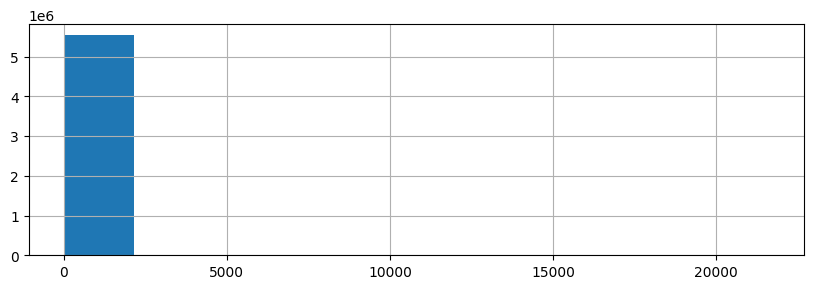

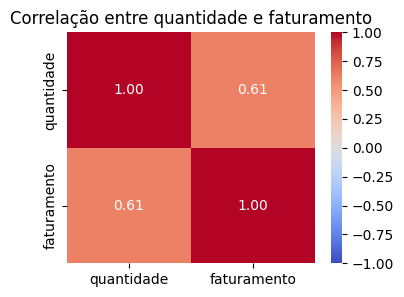

In [122]:
# Coluna de quantidade segue o mesmo padrão
display(df_vendas.quantidade.hist(figsize=(10, 3)))

# Matriz de correlação para as duas colunas
corr_matrix = df_vendas[['quantidade', 'faturamento']].corr()

# Heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

plt.title('Correlação entre quantidade e faturamento')
plt.show()

### a